## Analysing Flow Cytometry Dataset

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('/Users/hilde/Desktop/CytoFit/testing_kaggle/rituximab.csv')
print(df.head())

   FSC.H  SSC.H  FL1.H  FL2.H  FL3.H  FL1.A  FL1.W  Time  Gate
0    309    376    264    198    313      0      0     2     1
1     83     55    139     51    146      0      0     2     1
2    184    198    232     83    124      0      0     2     1
3    169     75    696     22    193    121     26     2     2
4    212     98    166      0    221      0      0     2     1


In [2]:
df.tail()

,FSC.H,SSC.H,FL1.H,FL2.H,FL3.H,FL1.A,FL1.W,Time,Gate
1540,340,460,249,23,363,0,0,598,1
1541,124,149,445,129,83,9,0,598,1
1542,678,327,274,196,259,0,0,598,-1
1543,722,443,871,218,714,675,279,598,2
1544,277,1023,398,355,120,4,0,598,-1


Shape: Returns (rows, columns) — so you can see how many cells were measured and how many parameters were recorded

In [6]:
df.shape

(1545, 9)

Dtypes: Tells you if each column is a number (int64, float64) or text (object)

In [7]:
df.dtypes

FSC.H    int64
SSC.H    int64
FL1.H    int64
FL2.H    int64
FL3.H    int64
FL1.A    int64
FL1.W    int64
Time     int64
Gate     int64
dtype: object

Isnull: hows how many empty/missing values are in each column - important because missing values can affect your analysis

In [8]:
df.isnull().sum()

FSC.H    0
SSC.H    0
FL1.H    0
FL2.H    0
FL3.H    0
FL1.A    0
FL1.W    0
Time     0
Gate     0
dtype: int64

Summary statistics: shows mean, min, max and std - for flow cytometry this tells you the range of fluorescence intensities and scatter values across all measured cells

In [10]:
df.describe()

,FSC.H,SSC.H,FL1.H,FL2.H,FL3.H,FL1.A,FL1.W,Time,Gate
count,1545.000000,1545.000000,1545.000000,1545.000000,1545.000000,1545.00000,1545.000000,1545.000000,1545.000000
mean,287.082201,251.826537,349.163754,126.399353,258.344984,73.45890,17.598706,294.038835,0.968932
std,178.193127,186.647075,234.347550,90.839352,192.264975,195.15186,56.391323,177.554519,0.795270
min,59.000000,11.000000,0.000000,0.000000,1.000000,0.00000,0.000000,2.000000,-1.000000
25%,178.000000,130.000000,197.000000,55.000000,150.000000,0.00000,0.000000,140.000000,1.000000
50%,249.000000,199.000000,244.000000,116.000000,203.000000,0.00000,0.000000,285.000000,1.000000
75%,331.000000,307.000000,445.000000,185.000000,315.000000,8.00000,0.000000,451.000000,1.000000
max,1023.000000,1023.000000,974.000000,705.000000,1023.000000,1023.00000,444.000000,598.000000,2.000000


## Analysis of data

How many cells in each gate?

In [12]:
df['Gate'].value_counts()

Gate
 1    1080
 2     294
-1     171
Name: count, dtype: int64

Average fluroesence per gate

In [13]:
df.groupby('Gate')[['FL1.H', 'FL2.H', 'FL3.H']].mean()

,FL1.H,FL2.H,FL3.H
Gate,,,
-1,519.017544,203.812865,464.210526
1,228.646296,101.372222,192.078704
2,693.088435,173.309524,382.034014


## FSC vs SSC scatter plot (classic flot cytometry plot)

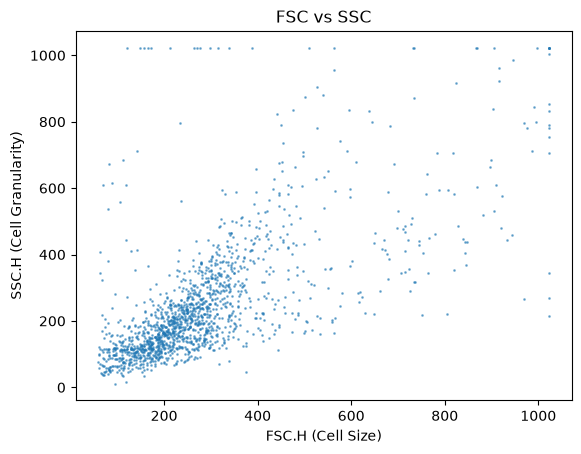

In [19]:
plt.scatter(df['FSC.H'], df['SSC.H'], alpha=0.5, s=1)
plt.xlabel('FSC.H (Cell Size)')
plt.ylabel('SSC.H (Cell Granularity)')
plt.title('FSC vs SSC')
plt.show()

## Colour cells by gate

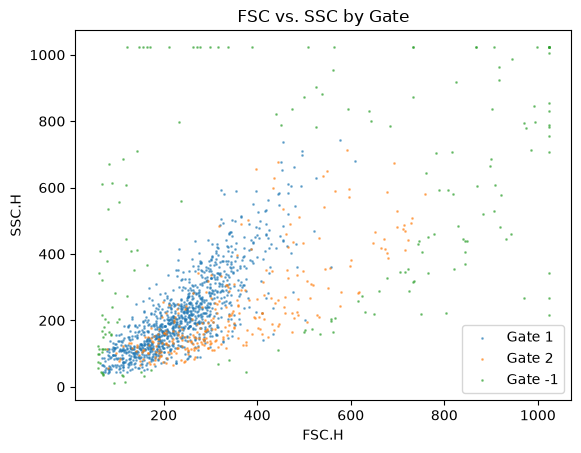

In [23]:
for gate in df['Gate'].unique():
    subset = df[df['Gate'] == gate]
    plt.scatter(subset['FSC.H'], subset['SSC.H'], alpha=0.5, s=1, label=f'Gate {gate}')

plt.xlabel('FSC.H')
plt.ylabel('SSC.H')
plt.title('FSC vs. SSC by Gate')
plt.legend()
plt.show()
    

## Fluroesence distribution per channel

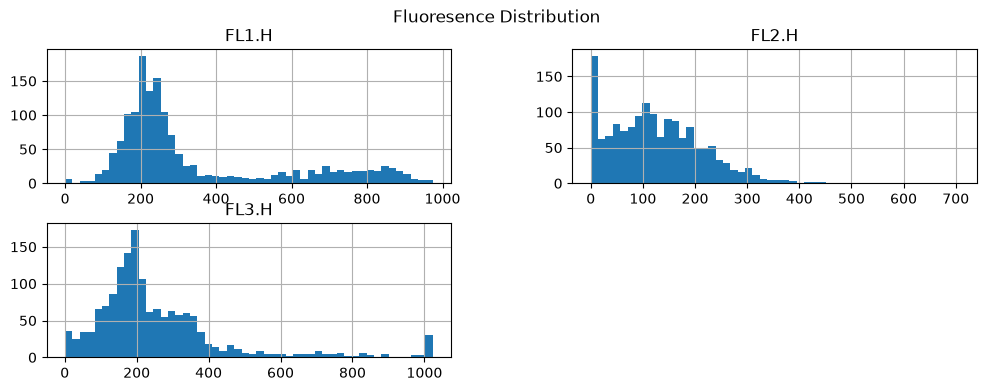

In [24]:
df[['FL1.H', 'FL2.H', 'FL3.H']].hist(bins=50, figsize=(12,4))
plt.suptitle('Fluoresence Distribution')
plt.show()

## Corrolation between channels

In [25]:
df[['FSC.H', 'SSC.H', 'FL1.H', 'FL2.H', 'FL3.H']].corr()

,FSC.H,SSC.H,FL1.H,FL2.H,FL3.H
FSC.H,1.000000,0.671943,0.605853,0.597848,0.830863
SSC.H,0.671943,1.000000,0.275019,0.620907,0.481638
FL1.H,0.605853,0.275019,1.000000,0.550808,0.690957
FL2.H,0.597848,0.620907,0.550808,1.000000,0.494148
FL3.H,0.830863,0.481638,0.690957,0.494148,1.000000


## FL1 vs FL2 scatter plot

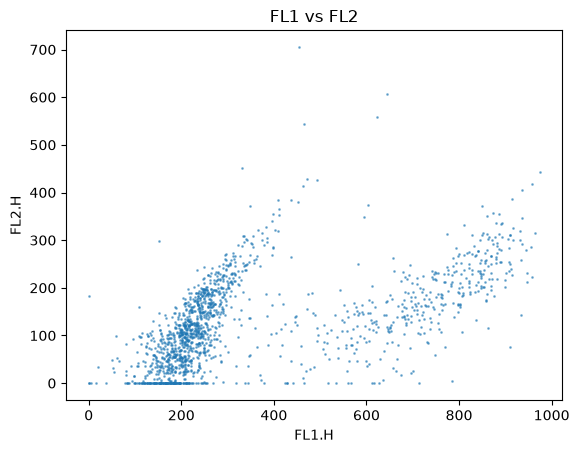

In [26]:
plt.scatter(df['FL1.H'], df['FL2.H'], alpha=0.5, s=1)
plt.xlabel('FL1.H')
plt.ylabel('FL2.H')
plt.title('FL1 vs FL2')
plt.show()

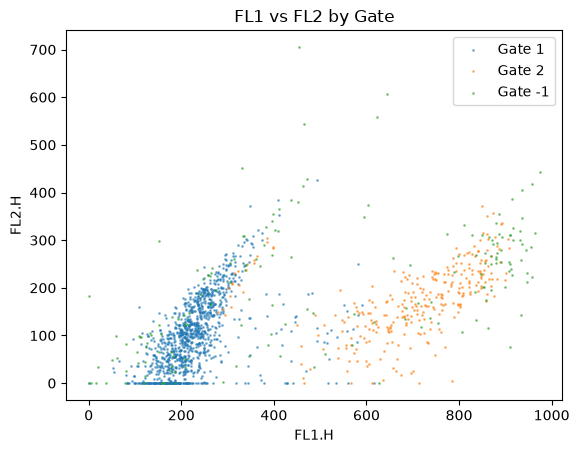

In [30]:
for gate in df['Gate'].unique():
    subset = df[df['Gate'] == gate]
    plt.scatter(subset['FL1.H'], subset['FL2.H'], alpha=0.5, s=1, label=f'Gate {gate}')
plt.xlabel('FL1.H')
plt.ylabel('FL2.H')
plt.title('FL1 vs FL2 by Gate')
plt.legend()
plt.show()

## Distribution of cell size (FSC) by gate

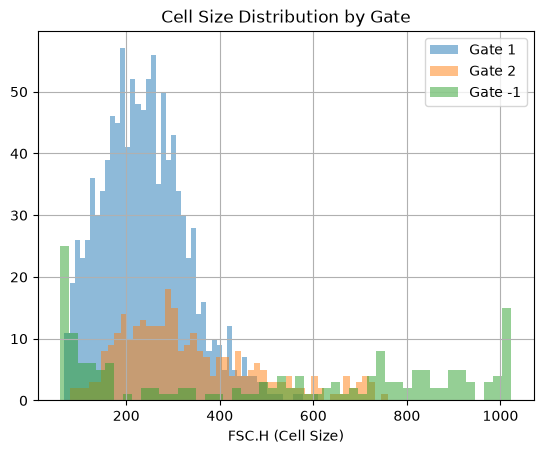

In [31]:
for gate in df['Gate'].unique():
    subset = df[df['Gate'] == gate]
    subset['FSC.H'].hist(bins=50, alpha=0.5, label=f'Gate {gate}')
plt.xlabel('FSC.H (Cell Size)')
plt.title('Cell Size Distribution by Gate')
plt.legend()
plt.show()

## Box plot of fluoresence by gate 

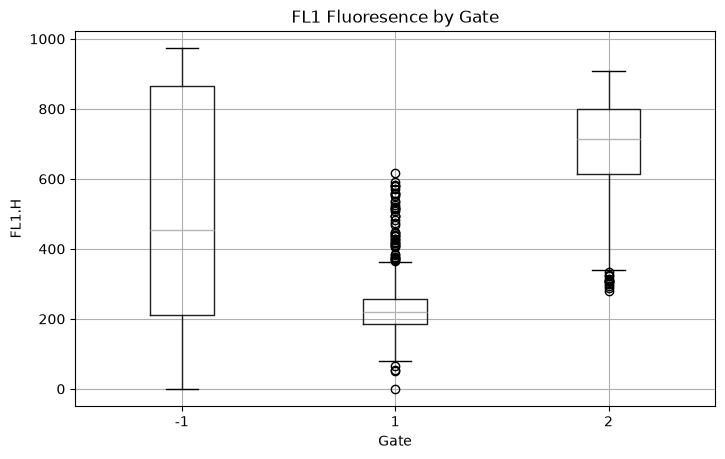

In [32]:
df.boxplot(column='FL1.H', by='Gate', figsize=(8, 5))
plt.title('FL1 Fluoresence by Gate')
plt.suptitle('')
plt.xlabel('Gate')
plt.ylabel('FL1.H')
plt.show()

## Time series - how cell measurements change over time

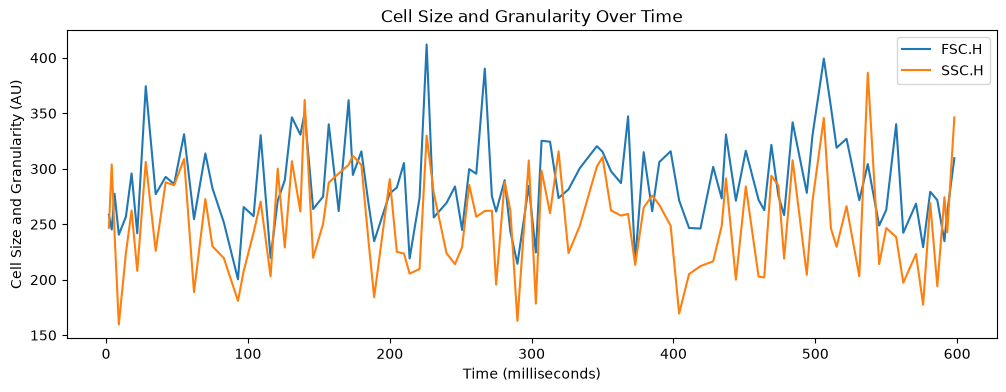

In [36]:
df.groupby('Time')[['FSC.H', 'SSC.H']].mean().plot(figsize=(12, 4))
plt.title('Cell Size and Granularity Over Time')
plt.xlabel('Time (milliseconds)')
plt.ylabel('Cell Size and Granularity (AU)')
plt.show()

## Identify dead vs. live cells (small FSC = dead cells)

In [39]:
live = df[df['FSC.H'] > 200]
dead = df[df['FSC.H'] <= 200]
print(f'Live cells: {len(live)}')
print(f'Dead cells: {len(dead)}')

Live cells: 1031
Dead cells: 514


## Compare FL1 between gates with boxplots

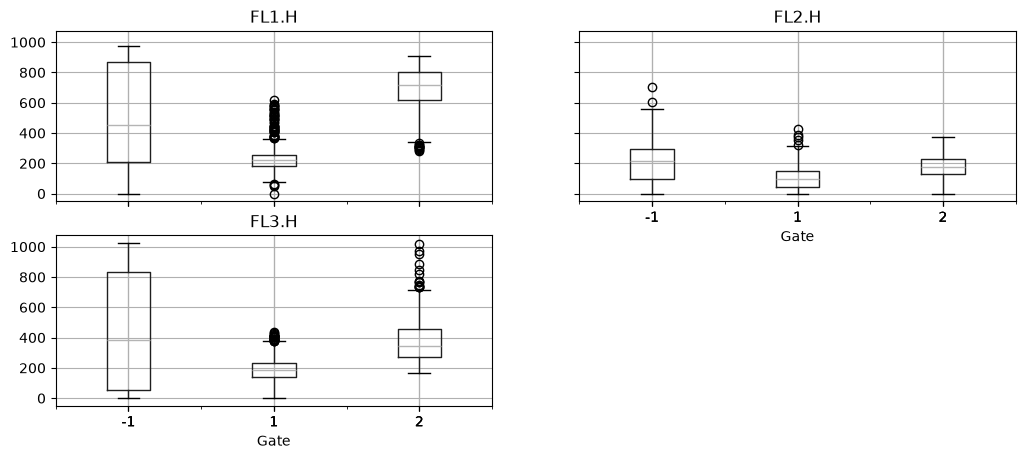

In [42]:
df.boxplot(column=['FL1.H', 'FL2.H', 'FL3.H'], by='Gate', figsize=(12,5))
plt.suptitle('')
plt.title('Fluoresence Channels by Gate')
plt.show()

# Complare FL1 between gates with violin plots

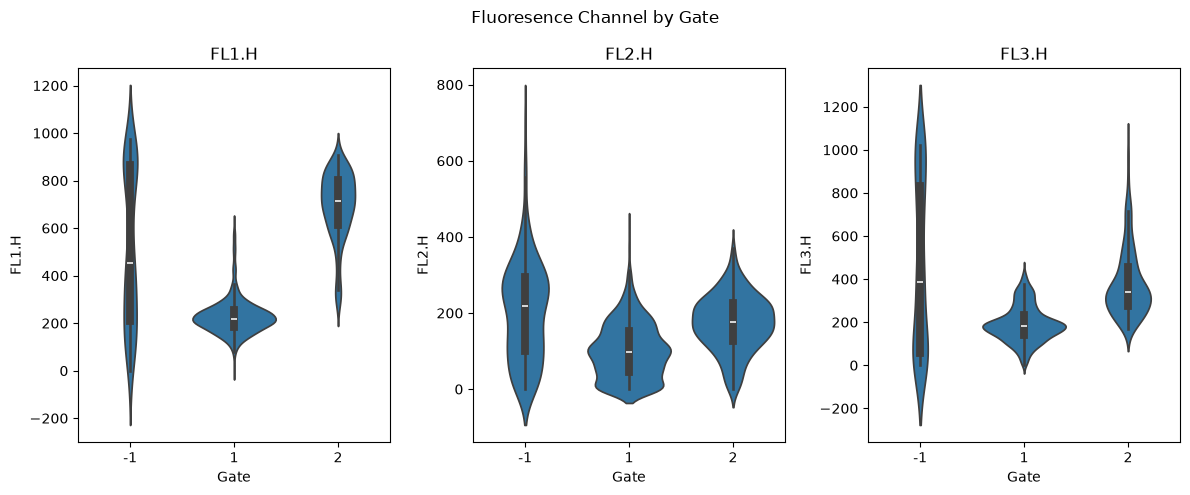

In [45]:
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(12, 5))

for ax, channel in zip(axes, ['FL1.H', 'FL2.H', 'FL3.H']):
    sns.violinplot(x='Gate', y=channel, data=df, ax=ax)
    ax.set_title(channel)

plt.suptitle('Fluoresence Channel by Gate')
plt.tight_layout()
plt.show()

# Coefficient of variation (CV) per channel - measures consistency 

In [46]:
cv = (df[['FSC.H', 'SSC.H', 'FL1.H', 'FL2.H', 'FL3.H']].std() / 
      df[['FSC.H', 'SSC.H', 'FL1.H', 'FL2.H', 'FL3.H']].mean() * 100)

print('Coefficient of Variation (%):')
print(cv.round(2))

Coefficient of Variation (%):
FSC.H    62.07
SSC.H    74.12
FL1.H    67.12
FL2.H    71.87
FL3.H    74.42
dtype: float64


## Heatmap of correlations between all channels

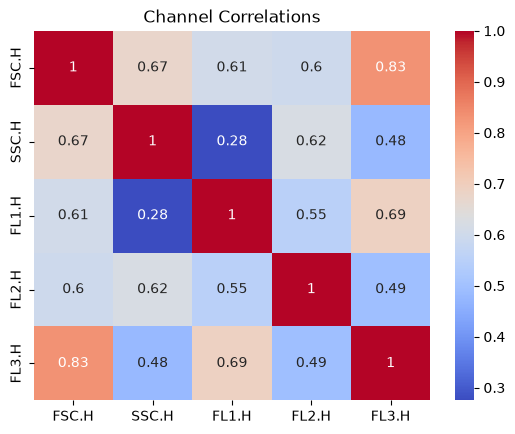

In [49]:
corr = df[['FSC.H', 'SSC.H', 'FL1.H', 'FL2.H', 'FL3.H']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Channel Correlations')
plt.show()